# Week 2: Biomarker Correlation and Exploratory Data Analysis (EDA)

## Objective
The objective of this phase is to explore relationships between clinical biomarkers and heart disease outcomes using statistical visualizations and correlation analysis.

In [ ]:
#Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r"../data/cleaned_heart_disease_dataset.csv")
df.head()

,Age,Gender,Chest_Pain_Type,Resting_Blood_Pressure,Cholesterol,Fasting_Blood_Sugar,Resting_ECG,Max_Heart_Rate,Exercise_Induced_Angina,ST_Depression,ST_Slope,Major_Vessels,Thalassemia,Heart_Disease
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      297 non-null    int64  
 1   Gender                   297 non-null    int64  
 2   Chest_Pain_Type          297 non-null    int64  
 3   Resting_Blood_Pressure   297 non-null    int64  
 4   Cholesterol              297 non-null    int64  
 5   Fasting_Blood_Sugar      297 non-null    int64  
 6   Resting_ECG              297 non-null    int64  
 7   Max_Heart_Rate           297 non-null    int64  
 8   Exercise_Induced_Angina  297 non-null    int64  
 9   ST_Depression            297 non-null    float64
 10  ST_Slope                 297 non-null    int64  
 11  Major_Vessels            297 non-null    int64  
 12  Thalassemia              297 non-null    int64  
 13  Heart_Disease            297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage

# Univariate Analysis


## Heart Disease Distribution

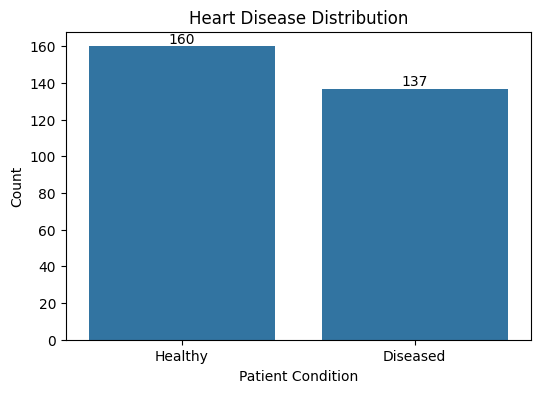

In [ ]:
#Visualization of healthy and diseased patient distribution within the dataset.
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x=df['Heart_Disease'].map({
        0: 'Healthy',
        1: 'Diseased'
    })
)

# Show counts on bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Heart Disease Distribution")

plt.xlabel("Patient Condition")
plt.ylabel("Count")

plt.show()

### Insight of heart disease distribution
The dataset contains 160 healthy patients and 137 diseased patients, indicating a reasonably balanced class distribution between the two groups. This balanced distribution is beneficial for machine learning tasks because it helps reduce prediction bias toward a single class. Additionally, the presence of both healthy and diseased patient records supports meaningful comparative analysis of cardiovascular biomarkers and heart disease risk factors.

## Age Distribution

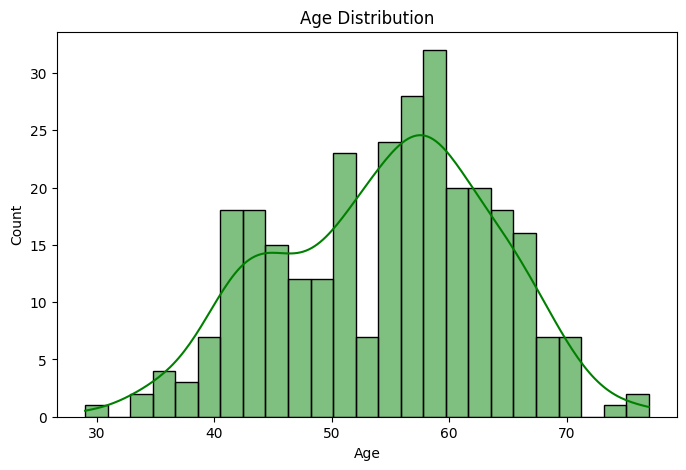

In [ ]:
# Visualization of Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'],
             bins=25,
             kde=True,
             color='green')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Age Distribution Insights
The age distribution shows that the highest concentration of patients is observed between 50 and 60 years of age, with the peak occurring near age 60. Patient frequency is comparatively lower in other age groups, indicating that middle-aged and older adults represent the dominant population in the dataset.
This trend suggests that increasing age may be strongly associated with higher cardiovascular disease risk.

## Gender Distribution

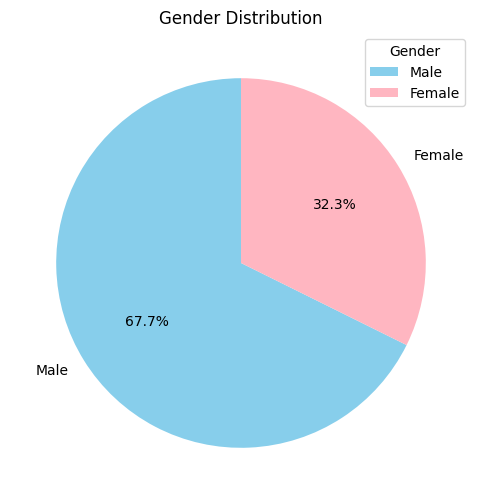

In [ ]:
# pie chart for Gender distribution
df['Gender'] = df['Gender'].replace({
    0: 'Female',
    1: 'Male'
})
# Count gender values
gender_counts = df['Gender'].value_counts()
# Create pie chart
plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    pctdistance=0.6,   # moves percentage toward center
    startangle=90,
    colors=['skyblue', 'lightpink']
)
# Add legend
plt.legend(
    title="Gender",
    loc="upper right"
)

plt.title("Gender Distribution")

plt.show()

### Insights of gender distribution

Male patients represent 67.7% of the dataset, while female patients account for 32.3%. This indicates a higher representation of males in the heart disease dataset, suggesting that gender may play an important role in cardiovascular risk analysis.

## Cholesterol Distribution

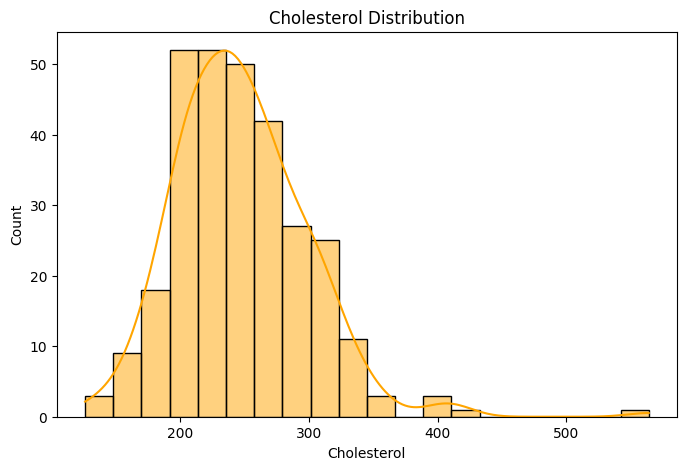

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Cholesterol'],
             bins=20,
             kde=True,
             color='orange')

plt.title("Cholesterol Distribution")

plt.xlabel("Cholesterol")
plt.ylabel("Count")

plt.show()

### Insights of Cholesterol Distribution
Most people in this dataset have borderline or high cholesterol (200–320 mg/dL), indicating a generally high-risk population for cardiovascular disease. A small number of extreme outliers suggest severe conditions like Hypercholesterolemia.
Overall, it points to weak preventive care and strong demand for screening and lifestyle intervention programs.

## Blood Pressure Distribution

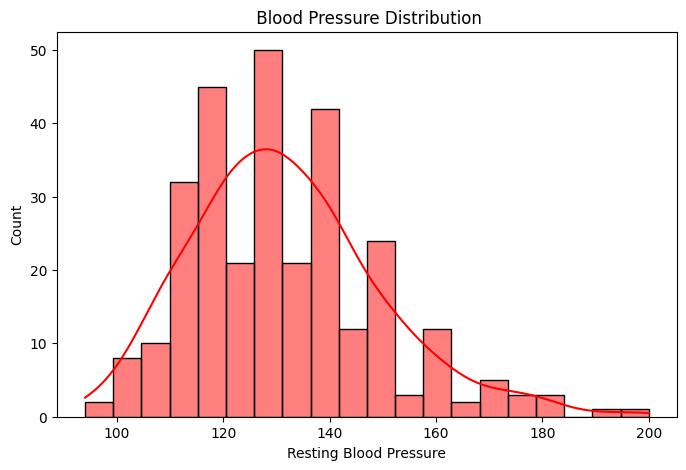

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Resting_Blood_Pressure'],
             bins=20,
             kde=True,
             color='red')

plt.title(" Blood Pressure Distribution")

plt.xlabel("Resting Blood Pressure")
plt.ylabel("Count")

plt.show()

### Insights of Blood Pressure Distribution
Most individuals fall in the elevated (120–129 mm Hg) and hypertensive (130–150 mm Hg) ranges, with only a small portion in the normal range. The right-skewed shape and tail up to 200 mm Hg show a significant high-risk subgroup with severe hypertension.
Overall, it indicates a generally high cardiovascular risk population needing intervention and monitoring.

## Max Heart Rate Distribution

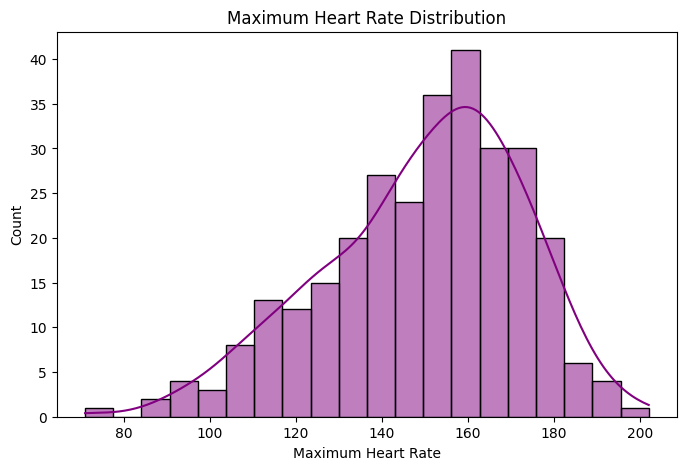

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Max_Heart_Rate'],
             bins=20,
             kde=True,
             color='purple')

plt.title("Maximum Heart Rate Distribution")

plt.xlabel("Maximum Heart Rate")
plt.ylabel("Count")

plt.show()

### Insights of Heart Rate Distribution
Most people have high max heart rates (135–175 bpm), peaking around 155–160 bpm, showing generally normal cardiovascular fitness. The left-skewed tail represents a small group with lower heart rate response due to age or medication.
Overall, the population is mostly healthy with a few low outliers.

# Bivariate Analysis

## Age vs Heart Disease

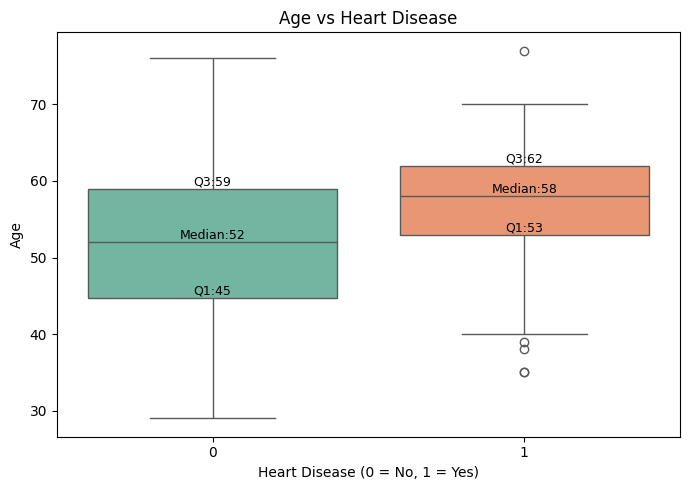

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.boxplot(
    x='Heart_Disease',
    y='Age',
    data=df,
    hue='Heart_Disease',   # FIX for seaborn warning
    palette='Set2',
    legend=False           # removes duplicate legend
)

# calculate Q1, Median, Q3
q1 = df.groupby('Heart_Disease')['Age'].quantile(0.25)
median = df.groupby('Heart_Disease')['Age'].median()
q3 = df.groupby('Heart_Disease')['Age'].quantile(0.75)

# add text on plot
for i in q1.index:
    plt.text(i, q1[i], f"Q1:{q1[i]:.0f}", ha='center', va='bottom', fontsize=9)
    plt.text(i, median[i], f"Median:{median[i]:.0f}", ha='center', va='bottom', fontsize=9)
    plt.text(i, q3[i], f"Q3:{q3[i]:.0f}", ha='center', va='bottom', fontsize=9)

plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

### Insights of Age vs Heart Disease
Individuals with heart disease are generally older, showing a higher median age than those without. Most cases cluster between 50–62 years, indicating a strong age-related risk. A few younger outliers suggest heart disease can still occur early due to other factors.

## Cholesterol vs Heart Disease

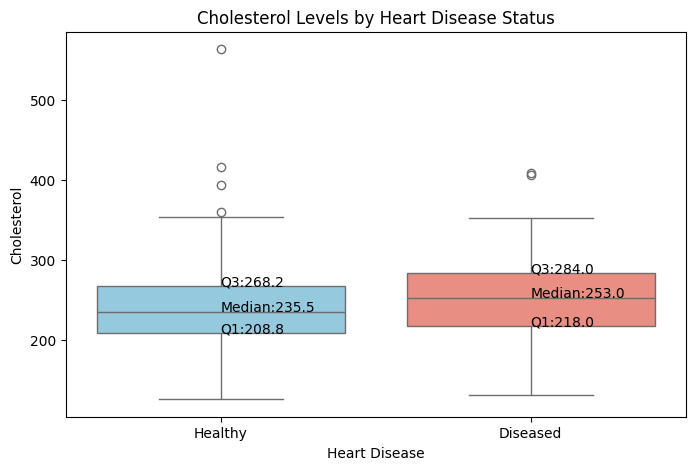

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    x='Heart_Disease',
    y='Cholesterol',
    hue='Heart_Disease',
    data=df,
    palette=['skyblue', 'salmon'],
    legend=False
)

# Rename labels
ax.set_xticks([0,1])
ax.set_xticklabels(['Healthy', 'Diseased'])

# Calculate statistics
for i, group in enumerate(df.groupby('Heart_Disease')['Cholesterol']):

    values = group[1]

    median = values.median()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    # Add text
    plt.text(i, median,
             f'Median:{median:.1f}',
             ha='left',
             color='black')

    plt.text(i, q1,
             f'Q1:{q1:.1f}',
             ha='left',
             color='black')

    plt.text(i, q3,
             f'Q3:{q3:.1f}',
             ha='left',
             color='black')

plt.title("Cholesterol Levels by Heart Disease Status")

plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol")

plt.show()

### Insights

Patients with heart disease generally show higher cholesterol levels compared to healthy individuals. The diseased group has a higher median cholesterol value and greater variability, indicating that elevated cholesterol may contribute significantly to cardiovascular disease risk.

# Advanced Exploratory Data Analysis (EDA)

## Chest Pain Type vs Heart Disease

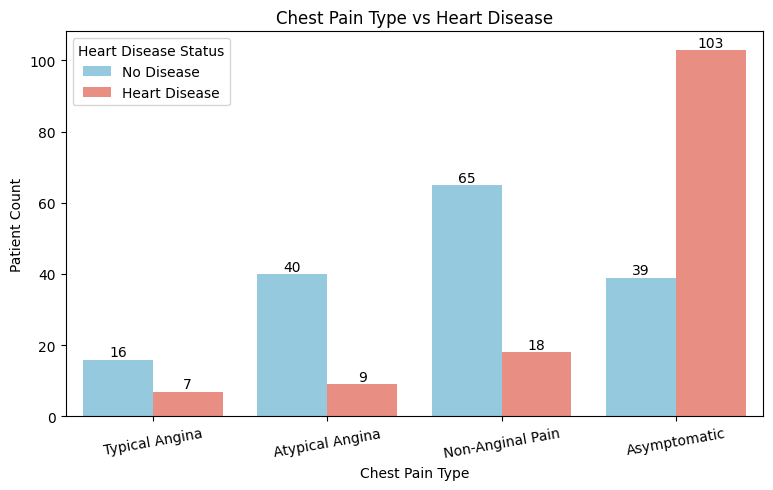

In [ ]:
plt.figure(figsize=(9,5))

ax = sns.countplot(
    x=df['Chest_Pain_Type'].map({
        0: 'Typical Angina',
        1: 'Atypical Angina',
        2: 'Non-Anginal Pain',
        3: 'Asymptomatic'
    }),

    hue=df['Heart_Disease'].map({
        0: 'No Disease',
        1: 'Heart Disease'
    }),

    palette=['skyblue', 'salmon']
)

# Add counts on bars
for bars in ax.containers:
    ax.bar_label(bars)

plt.title("Chest Pain Type vs Heart Disease")

plt.xlabel("Chest Pain Type")
plt.ylabel("Patient Count")

plt.legend(title="Heart Disease Status")

plt.xticks(rotation=10)

plt.show()

### Insights
Patients with asymptomatic chest pain show the highest occurrence of heart disease compared to other chest pain categories. In contrast, typical and atypical angina are more common among patients without heart disease.
This suggests that chest pain type is an important clinical indicator in cardiovascular disease prediction.